# DSSP2026 — `Experiment` and `Report`, end to end

This notebook is a guided tour of the two core objects in DSSP2026:

- **`Experiment`** — runs a study: tunes each model family, evaluates them, and
  persists everything needed to compare, optimize, and ensemble models later.
- **`Report`** — a read-only analysis API over the `report.db` an Experiment
  produces.

We use a hospital-readmission dataset (predicting whether a patient is
readmitted). The target is **heavily imbalanced (~6% positive)** — which is
exactly why decision-threshold tuning and cost-sensitive analysis matter here,
and why this makes a good showcase.

## 0. You are responsible for preprocessing

**The Experiment expects data that is already model-ready.** It does *not* clean
or encode your features for you. Before you build an Experiment you must handle:

- **Missing values** — impute or drop; the models will not do it for you.
- **Categorical encoding** — one-hot (or otherwise numerically encode) any
  string/categorical columns *yourself*. The schema role `"categorical"` means
  *"this column is already in numeric form, don't scale it"* — it does **not**
  trigger one-hot encoding.
- **Interactions / derived features** — if you want interaction terms or other
  engineered features, prepare them manually as columns. That's the safest,
  most explicit strategy.

The only feature transformation the framework applies is **standard-scaling the
columns you mark `"numeric"`**; everything else is passed through as-is. The
target is label-encoded internally where a model needs it.

Our dataset is already fully numeric with no missing values, so there's nothing
to encode here — but in general this preparation is on you.

In [1]:
import warnings
warnings.filterwarnings("ignore")  # quiet sklearn/statsmodels convergence chatter for the demo

import pandas as pd
from sklearn.model_selection import train_test_split

URL = ("https://raw.githubusercontent.com/BivinSadler/"
       "MDS-7374-Business-Analytics/refs/heads/master/"
       "Unit%208/hospital_readmission_data_1214.csv")

df = pd.read_csv(URL)
TARGET = "readmit"

print("shape:", df.shape)
print("\ndtypes:\n", df.dtypes)
print("\nmissing values:", int(df.isna().sum().sum()))
print("\nclass balance:\n", df[TARGET].value_counts(normalize=True).round(3))
df.head()

shape: (1214, 6)

dtypes:
 age                     int64
length_of_stay          int64
num_prior_admissions    int64
has_diabetes            int64
has_hypertension        int64
readmit                 int64
dtype: object

missing values: 0

class balance:
 readmit
0    0.938
1    0.062
Name: proportion, dtype: float64


,age,length_of_stay,num_prior_admissions,has_diabetes,has_hypertension,readmit
0,68,4,5,0,0,0
1,81,10,2,0,0,0
2,58,2,4,0,0,0
3,44,11,4,0,0,0
4,72,8,3,0,1,0


## 1. The three-way split: train / validation / test

The Experiment is **strictly built around three datasets**, each with a distinct
job — this separation is what keeps the final numbers honest:

| Split | Role |
|-------|------|
| **train** | Fit models; tune **hyperparameters** via internal cross-validation; tune **decision thresholds** via out-of-fold CV. |
| **validation** (`evaluation`) | **Model selection** and threshold/policy selection — choosing *which* model and decision rule wins. |
| **test** | The **least-biased evaluation**, used only for final reporting. Nothing in fitting or selection ever touches it. |

Why three and not two: whatever you *select* on becomes optimistically biased
(you kept the option that looked best on it). Selecting on validation and
reporting on test means the reported number isn't inflated by the search.

We make a stratified 60 / 20 / 20 split (stratified because the target is rare).

In [2]:
train_val, test = train_test_split(
    df, test_size=0.20, stratify=df[TARGET], random_state=42)
train, validation = train_test_split(
    train_val, test_size=0.25, stratify=train_val[TARGET], random_state=42)

print(f"train:      {len(train):>4}")
print(f"validation: {len(validation):>4}")
print(f"test:       {len(test):>4}")

train:       728
validation:  243
test:        243


## 2. Set up and run the Experiment

We declare a **schema** — a role for every feature column. This is required: the
Experiment fails loudly at construction if a feature column is missing a role or
absent from the data (a deliberate "fail at the boundary" guard).

- `"numeric"` → standard-scaled.
- `"categorical"` → passed through as-is (already numeric here: 0/1 flags).

The Experiment pipeline then, for each model family:
1. tunes hyperparameters with **internal k-fold CV** on train,
2. computes **out-of-fold** predictions on train (used later for leak-free
   threshold tuning),
3. refits on full train and **persists predictions on validation and test**,

…and records all of it in `report.db` so the Report layer can compare, optimize,
and ensemble models on the fly — without refitting.

In [3]:
schema = {
    "age":                  "numeric",
    "length_of_stay":       "numeric",
    "num_prior_admissions": "numeric",
    "has_diabetes":         "categorical",   # already 0/1 — passed through, not scaled
    "has_hypertension":     "categorical",
}

from DSSP2026.experiment.experiment import Experiment

exp = Experiment(
    train=train,
    evaluation=validation,
    test=test,
    target=TARGET,
    schema=schema,
    feature_sets={"all": list(schema)},
    experiment_dir="./readmission_run",
    n_trials=20,      # Optuna trials per tuned family
    n_splits=5,       # internal CV folds
    random_state=42,
)

exp.run()                 # runs all five model families with default search spaces
print("\nreport.db written to:", exp.report_db)

[20260608T023304] running study: Logistic regression
    best all | CV=0.7505 | eval F1=0.7681
[20260608T023304] running study: Decision tree
    best all | CV=0.7316 | eval F1=0.6794
[20260608T023304] running study: Random forest
    best all | CV=0.7532 | eval F1=0.7250
[20260608T023304] running study: MLP
    best all | CV=0.7569 | eval F1=0.6667
[20260608T023304] running study: XGBoost
    best all | CV=0.7804 | eval F1=0.7370
[20260608T023304] COMPLETE — ./readmission_run

report.db written to: readmission_run/report.db


## 3. Open the Report and ask what it can do

`Report.describe()` introspects the `report.db` and tells you which analyses are
available — and *why* any are not (e.g. logistic-only views, or analyses that
need the persisted test/OOF tables). It's the quickest way to orient yourself.

In [4]:
from DSSP2026.report import Report

r = Report(exp.report_db)
print(r.describe())

Report capabilities — experiment 20260608T023304
  models:   Decision tree, Logistic regression, MLP, Random forest, XGBoost, Ensemble
  policies: ArgMax, F1, Youden's J
  available analyses:
    • compare_models — per-model metrics table (test-scored when available)
    • confusion_matrix — confusion heatmap for a model + policy (policies: ArgMax, F1, Youden's J)
    • roc_compare — ROC curves across models
    • classification_report — per-class precision/recall/F1 table
    • feature_importance — feature-importance plot for a model
    • Ensemble views — mean-probability ensemble of 5 models (pass model='Ensemble')
    • best_fit — select on validation, report leak-free test metrics
    • fit — tune thresholds on train OOF, deploy a PolicyModel
    • cost_optimize — cost-sensitive (model x policy) sweep, test-scored
    • coefficients_table — logistic coefficients (refits on train frame)
    • odds_ratios_plot — logistic odds-ratio forest plot
    • tuning_plot — hyperparameter sear

## 4. The search space

Each tuned family has a **search space** — the hyperparameters and ranges Optuna
explored. You can inspect the built-in defaults, and (in Python) override them
via `Experiment(search_space=...)`. Random Forest uses an exhaustive **grid**;
the others use **TPE** (Bayesian) sampling.

In [5]:
from DSSP2026.experiment import spaces

# The built-in default search space, per model:
for model in ["Decision tree", "Random forest", "MLP", "XGBoost"]:
    print(f"--- {model} ---")
    for d in spaces.default_space(model):
        print("  ", d)
    print()

--- Decision tree ---
   {'name': 'max_depth', 'type': 'int', 'low': 1, 'high': 19}

--- Random forest ---
   {'name': 'n_estimators', 'type': 'categorical', 'choices': [50, 100, 200, 300]}
   {'name': 'max_features', 'type': 'categorical', 'choices': [2, 3, 5, 'sqrt', 'log2']}

--- MLP ---
   {'type': 'group', 'collect': 'hidden', 'count': {'name': 'n_layers', 'type': 'int', 'low': 1, 'high': 4}, 'item': {'name': 'width', 'type': 'int', 'low': 16, 'high': 512, 'log': True}}
   {'name': 'activation', 'type': 'categorical', 'choices': ['relu', 'tanh']}
   {'name': 'alpha', 'type': 'float', 'low': 1e-06, 'high': 10.0, 'log': True}
   {'name': 'lr_init', 'type': 'float', 'low': 0.0001, 'high': 0.1, 'log': True}

--- XGBoost ---
   {'name': 'n_estimators', 'type': 'int', 'low': 100, 'high': 600, 'step': 50}
   {'name': 'max_depth', 'type': 'int', 'low': 2, 'high': 10}
   {'name': 'learning_rate', 'type': 'float', 'low': 0.001, 'high': 0.3, 'log': True}
   {'name': 'subsample', 'type': 'flo

### Tuning plots

For each tuned family the Report can plot the search. The plot auto-routes by
search shape: an **elbow** for single-parameter searches, a **heatmap** for grids,
**parallel coordinates** for higher-dimensional TPE searches.

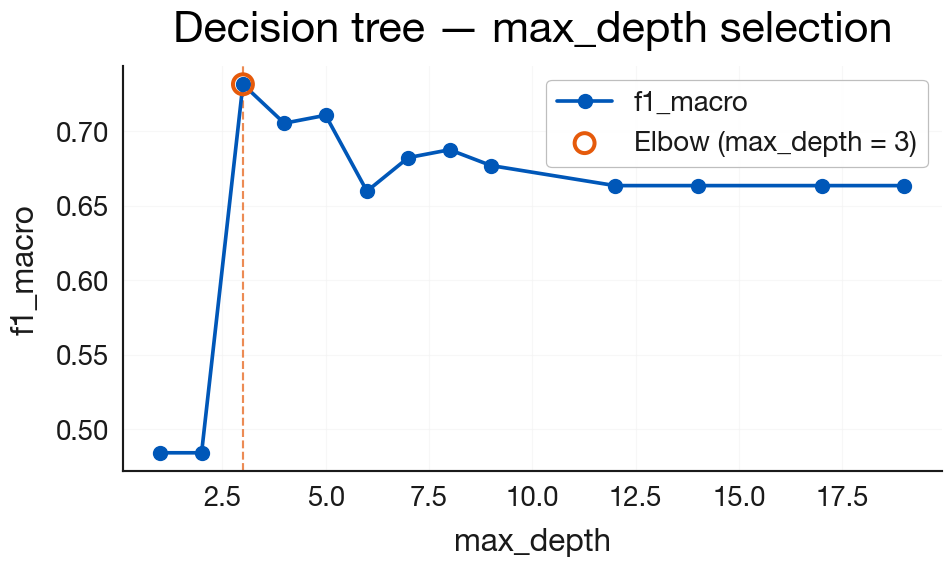

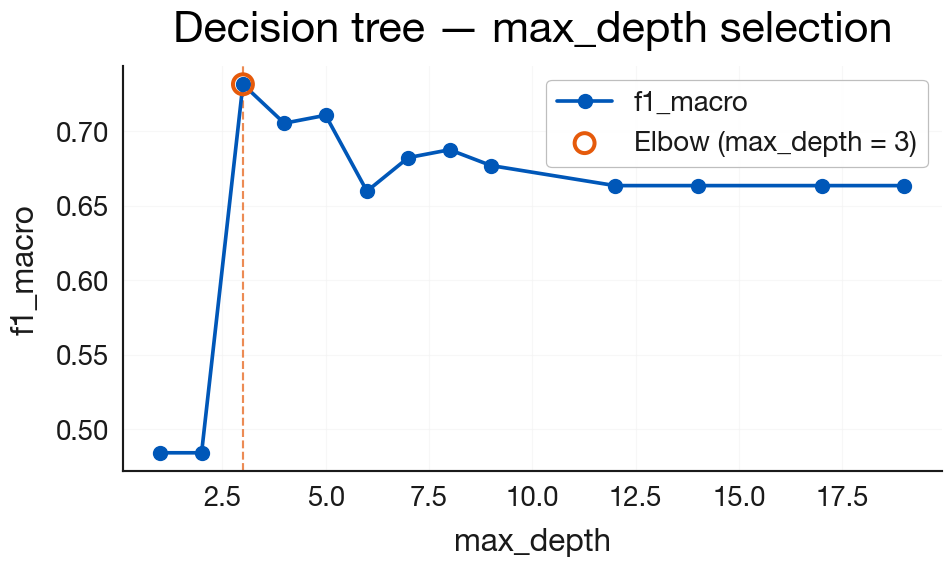

In [6]:
# Decision tree: single hyperparameter (max_depth) -> elbow-style plot
r.tuning_plot("Decision tree")

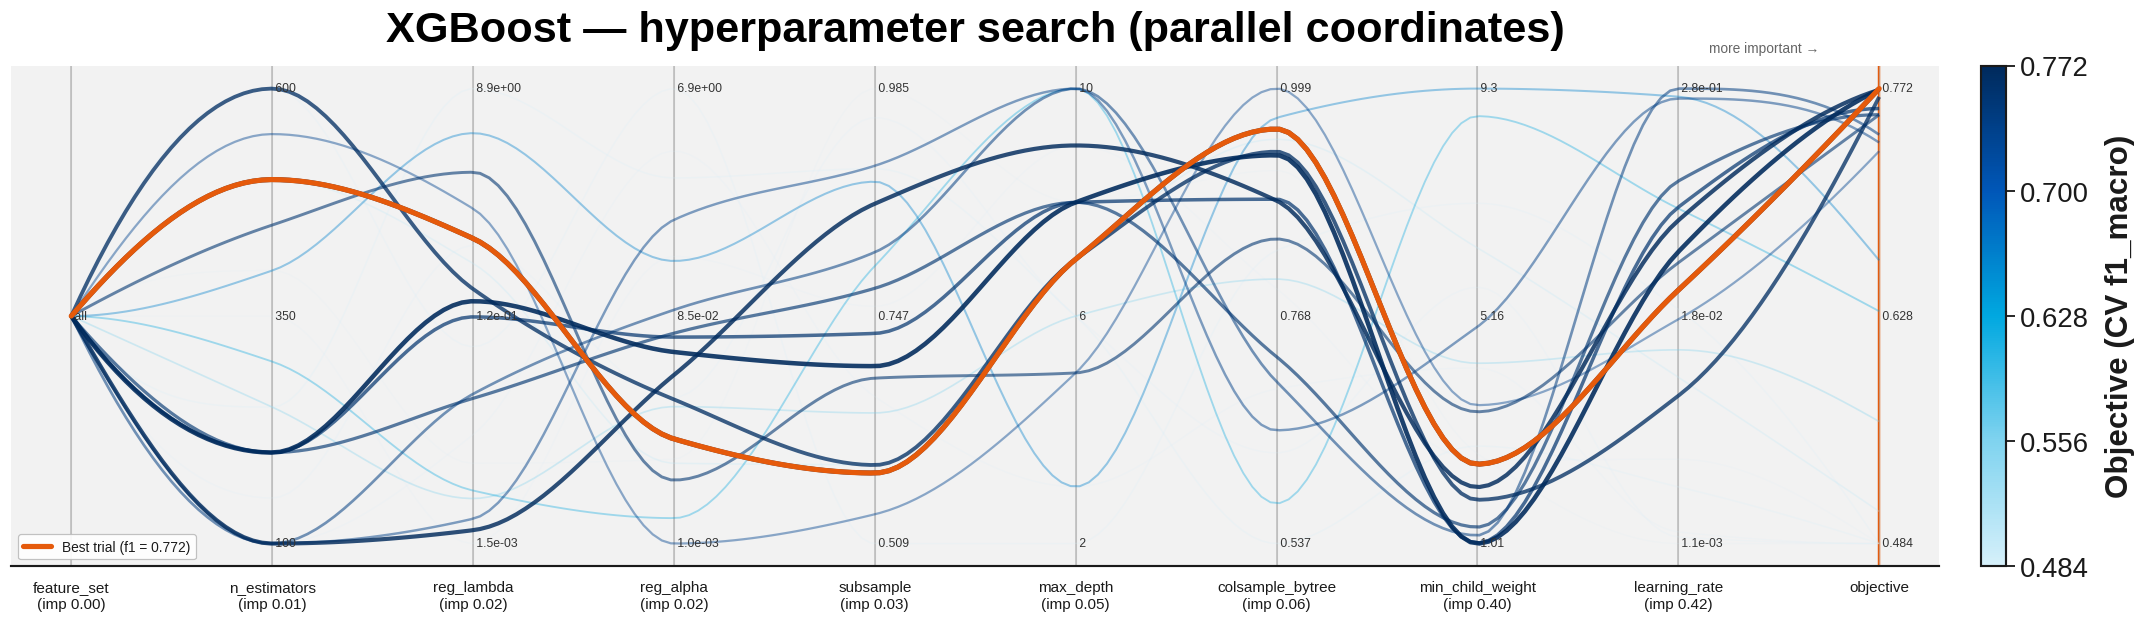

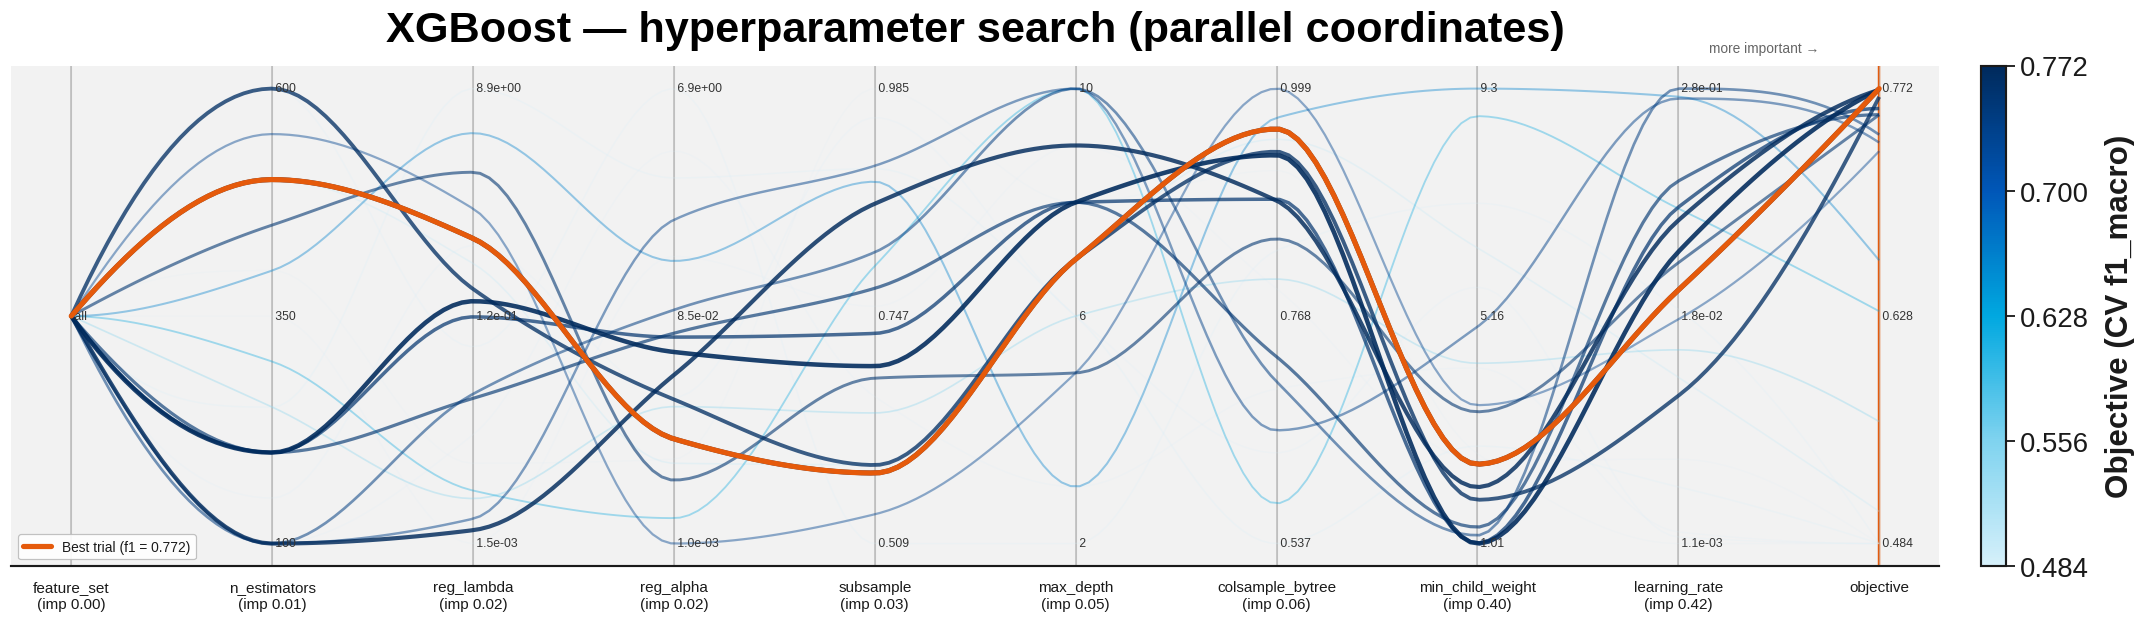

In [7]:
# XGBoost: multi-dimensional TPE search -> parallel-coordinates plot
r.tuning_plot("XGBoost")

## 5. Compare models

`compare_models()` gives one row per model (plus an **Ensemble** row — the
mean-probability ensemble of the real models), **scored on the held-out test
set**. The default decision rule is **ArgMax** (predict the highest-probability
class).

In [7]:
r.compare_models(allow_ensemble=True).df

,Model,Accuracy,Precision,Recall,F1
0,Ensemble,0.9588,0.7778,0.4667,0.5833
1,Logistic regression,0.9547,0.7000,0.4667,0.5600
2,MLP,0.9547,0.7000,0.4667,0.5600
3,Decision tree,0.9383,0.5000,0.4000,0.4444
4,XGBoost,0.9424,0.5556,0.3333,0.4167
5,Random forest,0.9342,0.4444,0.2667,0.3333


### ROC comparison

ROC curves are probability-based (threshold-independent), so they summarize each
model's ranking ability across all thresholds.

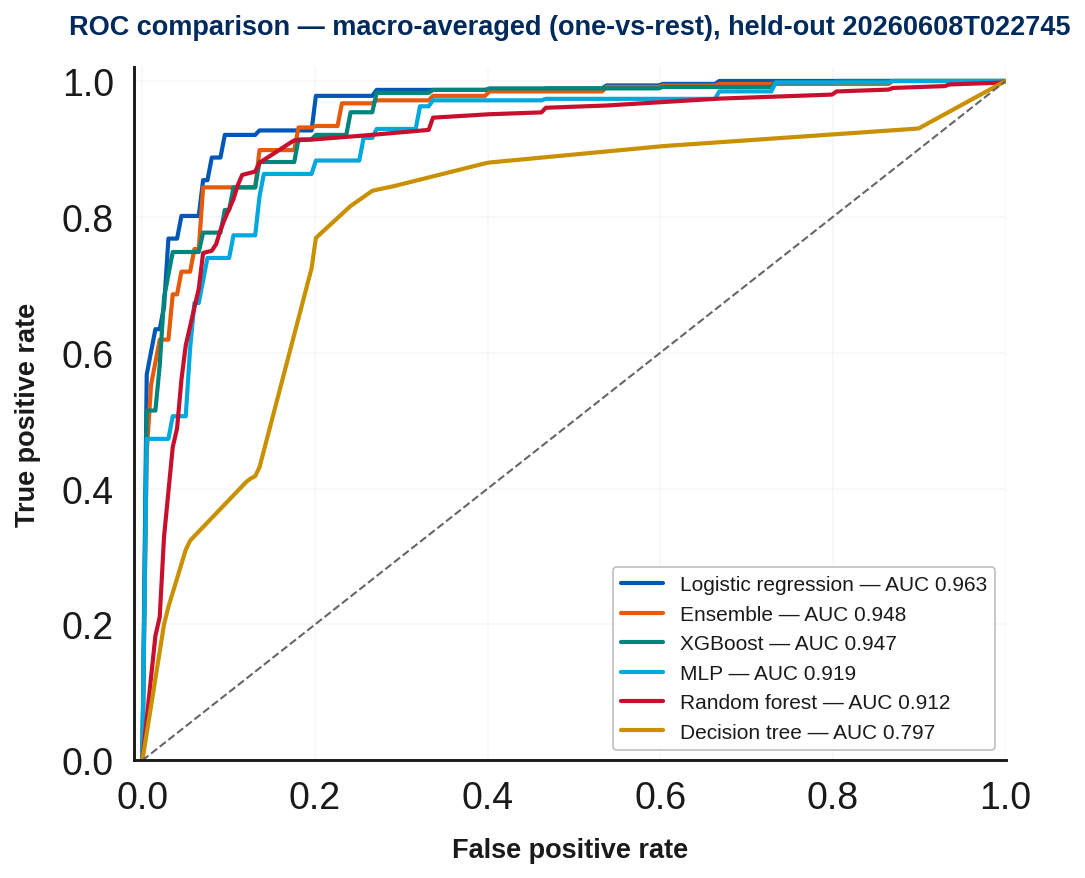

In [9]:
r.roc_compare(r.models(include_ensemble=True))

## 6. Decision policies: F1 and Youden's J

With a rare positive class, **ArgMax barely predicts the positive class at all** —
the default 0.5 cut is far too conservative. Decision **policies** tune per-class
thresholds toward a criterion:

- **F1** — balances precision and recall.
- **Youden's J** — maximizes (sensitivity + specificity − 1).

Thresholds are tuned on **train out-of-fold** predictions (leak-free), then
applied to test. Watch recall on the positive class change versus the ArgMax
table above.

In [8]:
# Same comparison table, but scored under the F1 policy:
r.compare_models(policy="F1", allow_ensemble=True).df

,Model,Accuracy,Precision,Recall,F1
0,Logistic regression,0.9547,0.6250,0.6667,0.6452
1,MLP,0.9547,0.6667,0.5333,0.5926
2,Ensemble,0.9588,0.7778,0.4667,0.5833
3,Decision tree,0.9383,0.5000,0.4000,0.4444
4,XGBoost,0.9465,0.6250,0.3333,0.4348
5,Random forest,0.9342,0.4444,0.2667,0.3333


In [11]:
# Youden's J policy:
r.compare_models(policy="Youden's J", allow_ensemble=True).df

,Model,Accuracy,Precision,Recall,F1
0,Decision tree,0.9259,0.4286,0.6000,0.5000
1,Ensemble,0.8848,0.3415,0.9333,0.5000
2,Logistic regression,0.8724,0.3182,0.9333,0.4746
3,XGBoost,0.8601,0.2889,0.8667,0.4333
4,MLP,0.8395,0.2692,0.9333,0.4179
5,Random forest,0.8313,0.2593,0.9333,0.4058


### `best_fit` — select on validation, report on test

`best_fit` sweeps the requested models × policies, **selects the winner on the
validation set** (so the choice doesn't peek at test), refits it, and reports its
**test** metrics. The returned object is a deployable model (`.predict` /
`.predict_proba`).

In [12]:
best = r.best_fit(allow_ensemble=True, target="F1")
print("winner:", best.model_type, "| policy:", best.policy)
print("validation score:", round(best.validation_score, 4))
print("TEST metrics:", best.test_metrics)

winner: Logistic regression | policy: F1
validation score: 0.5806
TEST metrics: {'accuracy': 0.9547, 'precision': 0.625, 'recall': 0.6667, 'f1': 0.6452}


## 7. Confusion matrices on test — with and without optimization

The confusion matrix is computed on **test**. Compare the default **ArgMax** rule
against an optimized policy (**F1**): on this imbalanced target, optimization
shifts the threshold so the model actually catches more of the rare positives —
trading a little overall accuracy for far better recall on the class we care
about.

Best model by validation F1: Logistic regression


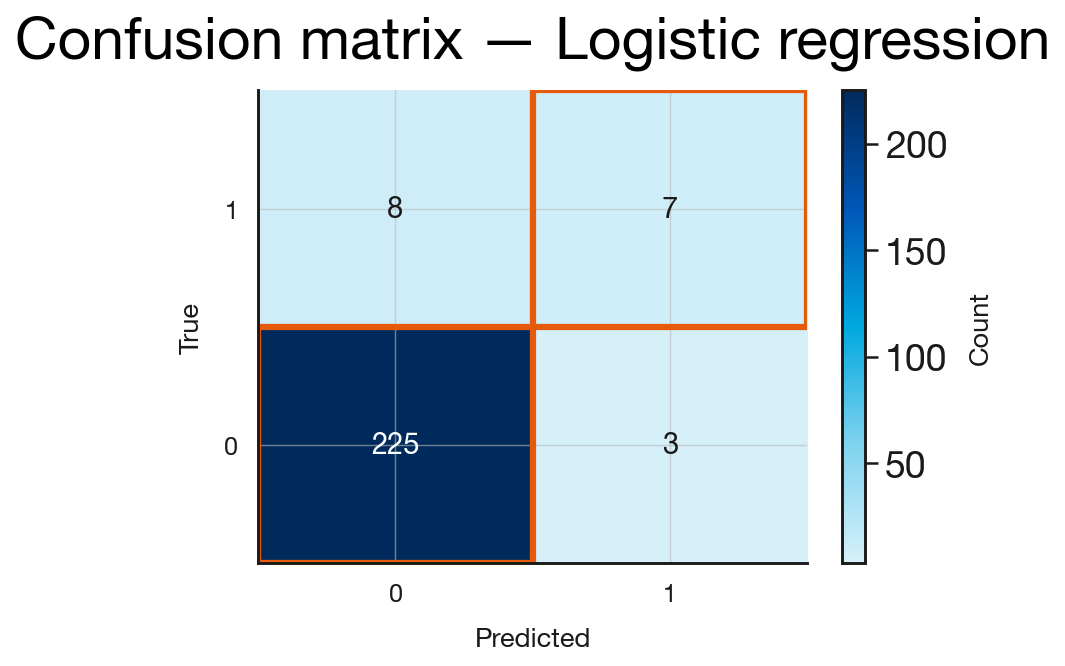

In [13]:
best_model = r._best_model_name()
print("Best model by validation F1:", best_model)

# Default ArgMax decisions on test:
r.confusion_matrix(best_model, policy="ArgMax")

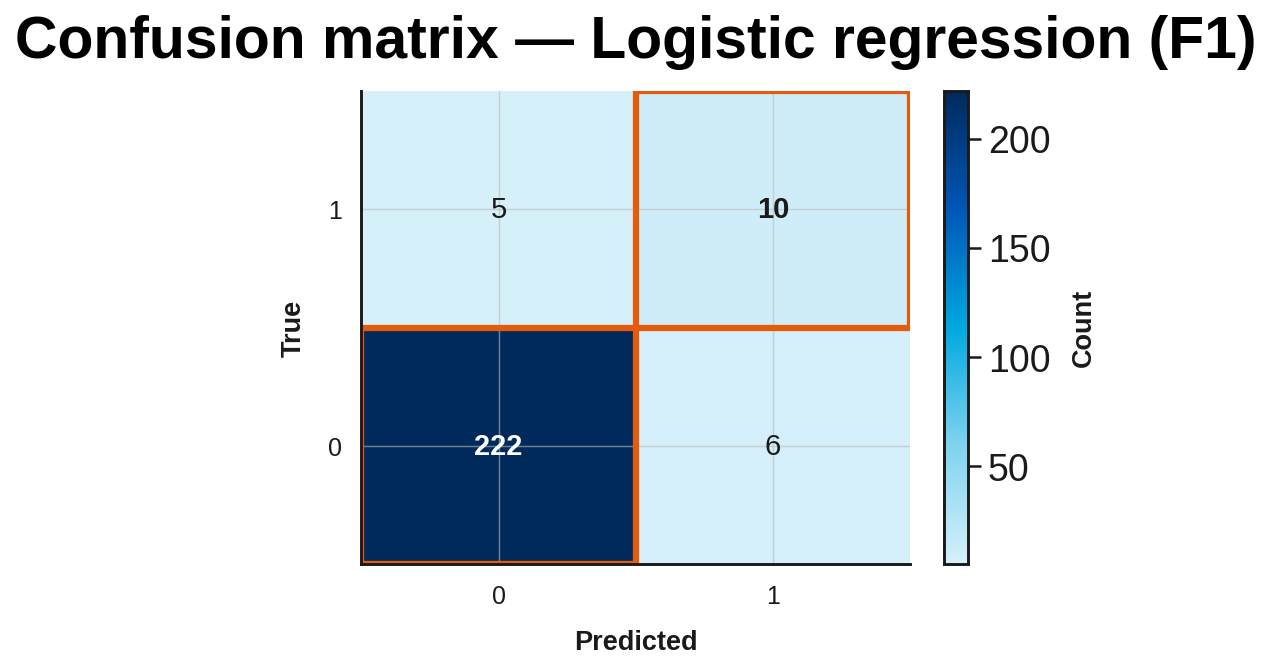

In [14]:
# Same model, F1-optimized threshold on test:
r.confusion_matrix(best_model, policy="F1")

## 8. Cost-sensitive optimization

When errors have **different dollar costs**, accuracy/F1 are the wrong objective.
`cost_optimize` takes a **payoff schedule** and finds the (model, policy)
combination that maximizes **net benefit** — tuning on train, selecting on
validation, reporting on test.

Here we encode a plausible readmission economics: a missed readmission (false
negative) is very expensive (\$8,000 in downstream cost), a correctly caught
readmission saves money (\$2,000), and an intervention on a non-readmit
(false positive) has a modest cost (\$500). The schedule is indexed by class
with columns `TP/FP` (acting on a case), `TP` (correct positive), `FN` (missed
positive).

In [14]:
payoff = pd.DataFrame(
    {"TP/FP": [-500.0, -500.0],
     "TP":    [0.0,    2000.0],
     "FN":    [0.0,   -8000.0]},
    index=[0, 1],   # class labels: 0 = no readmit, 1 = readmit
)
payoff

,TP/FP,TP,FN
0,-500.0,0.0,0.0
1,-500.0,2000.0,-8000.0


In [15]:
decision = r.cost_optimize(payoff, allow_ensemble=True)
print("Best by net benefit:", decision.model_type, "| policy:", decision.policy)
print("Net benefit (test):", round(decision.net_benefit, 0))

Best by net benefit: Decision tree | policy: Bayes
Net benefit (test): 8500.0


### The cost tables and plot

`cost_optimize` returns the full sweep and breakdowns:
- **policy table** — net benefit for every (model, policy) combination,
- **class breakdown** — where the benefit/cost comes from per class,
- **cost confusion matrix** — the confusion matrix shaded by dollar impact.

In [17]:
decision.policy_table.show()

Model,Policy,Investment,Loss,Gains,Gross,Net Benefit
No Action,—,$0,-$120.0k,$0,-$120.0k,$0
Decision tree,ArgMax,-$121.5k,-$72.0k,$12.0k,-$181.5k,-$61.5k
Decision tree,Bayes,-$121.5k,-$16.0k,$26.0k,-$111.5k,$8.5k


In [20]:
decision.class_breakdown.show()

Class,TP,FP,FN,TP Value,FP Value,FN Value,Net
0,23,2,205,-$11.5k,-$1.0k,$0,-$12.5k
1,13,205,2,$123.5k,-$102.5k,-$16.0k,$5.0k


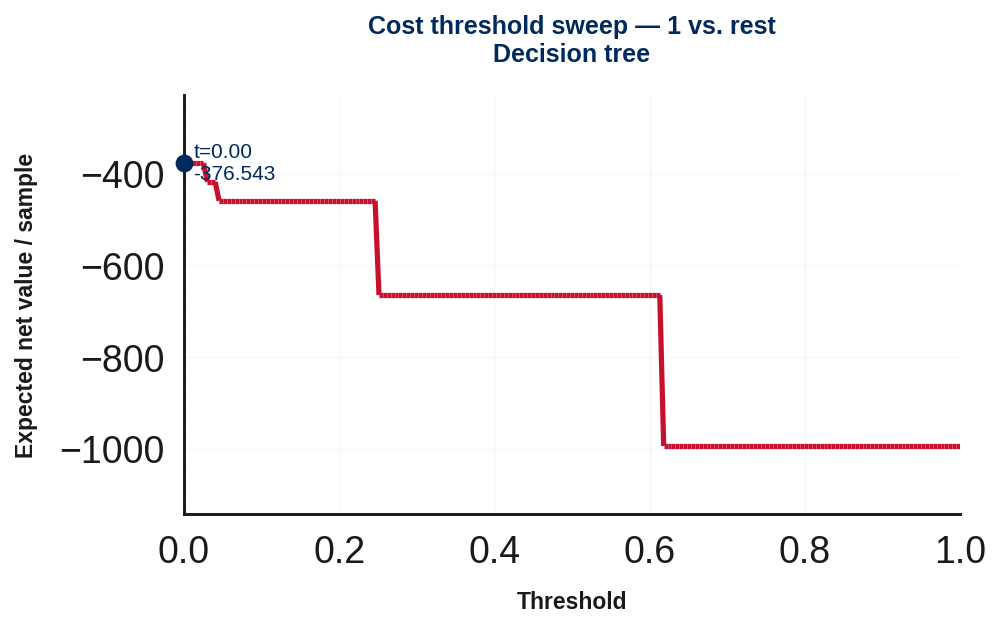

In [19]:
# Per-class cost-threshold plot for the winning model (class "1" = readmit):
r.cost_threshold_plot(payoff, model=decision.model_type, target_class="1")

## 9. Logistic coefficients (bonus)

Because a logistic model is present, the Report can also show interpretable
coefficient / odds-ratio views. (Coefficients aren't persisted, so these refit
the model on the training frame — hence they take `train` and `target`.)

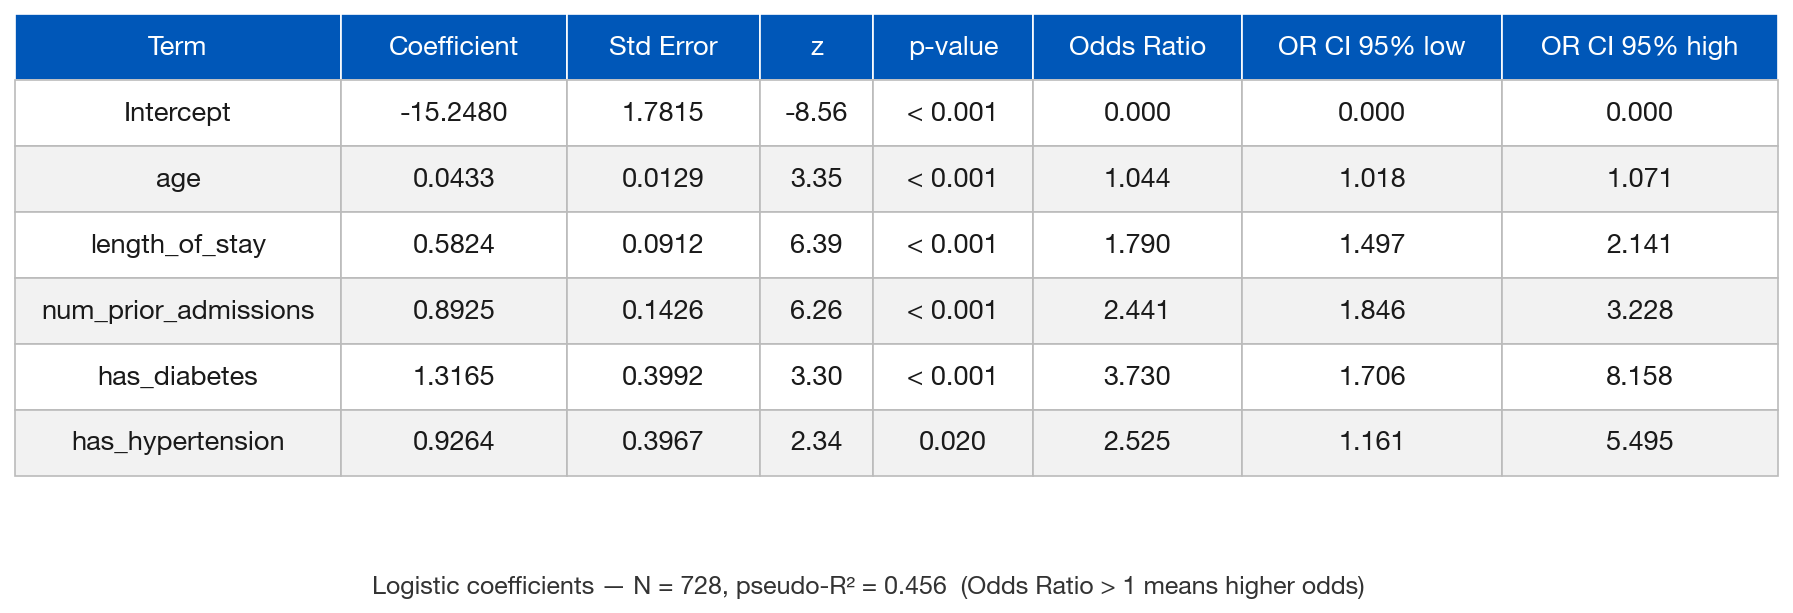

In [21]:
r.coefficients_table(train, TARGET)

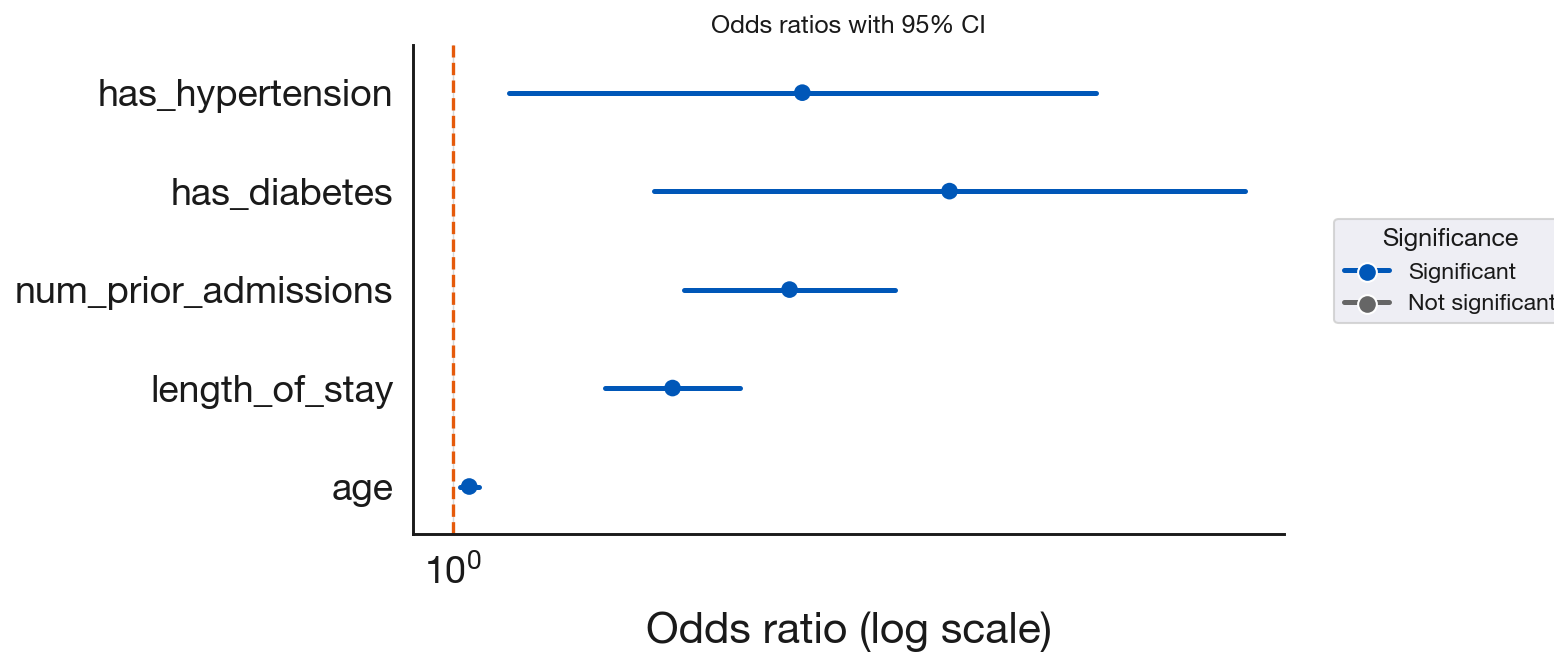

In [22]:
r.odds_ratios_plot(train, TARGET)

## Recap

- **`Experiment`** ran five model families on a strict **train / validation /
  test** split, tuning hyperparameters by internal CV, and persisted everything
  to `report.db`.
- **`Report`** then compared models on **test**, applied **F1 / Youden's J**
  decision policies (tuned leak-free on train OOF), selected a winner on
  **validation** with `best_fit`, drew **confusion matrices** with and without
  optimization, and ran a **cost-sensitive** sweep with full tables and plots.

The throughline: tune on train, select on validation, report on test — so every
headline number is one the selection process never got to peek at.